In [1]:
import pandas as pd

file_path = "../data/raw/DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    file_path,
    encoding="latin1"
)

print("Dataset loaded successfully!")

print("\nShape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset loaded successfully!

Shape:
(180519, 53)

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date

In [2]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')

In [3]:
print(df.isnull().sum())

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
print(df.describe(include='all'))

          Type  Days for shipping (real)  Days for shipment (scheduled)  \
count   180519             180519.000000                  180519.000000   
unique       4                       NaN                            NaN   
top      DEBIT                       NaN                            NaN   
freq     69295                       NaN                            NaN   
mean       NaN                  3.497654                       2.931847   
min        NaN                  0.000000                       0.000000   
25%        NaN                  2.000000                       2.000000   
50%        NaN                  3.000000                       4.000000   
75%        NaN                  5.000000                       4.000000   
max        NaN                  6.000000                       4.000000   
std        NaN                  1.623722                       1.374449   

        Benefit per order  Sales per customer Delivery Status  \
count       180519.000000       18

In [6]:
# 1. Convert date columns
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'], errors='coerce')

# 2. Handle missing values
df['Customer Lname'] = df['Customer Lname'].fillna("Unknown")
df['Customer Zipcode'] = df['Customer Zipcode'].fillna(-1)   # placeholder
df = df.drop(columns=['Order Zipcode', 'Product Description'])  # too many missing

# 3. Verify again
print(df.isnull().sum())

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Email                   0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Password                0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
order date (DateOrde

In [8]:
drop_columns = [
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Product Description",
    "Product Image"
]

# Drop safely (ignore if column not found)
df_clean = df.drop(columns=drop_columns, errors="ignore")

print("Cleaned Dataset Shape:", df_clean.shape)
print("\nRemaining Columns:")
print(df_clean.columns.tolist())

Cleaned Dataset Shape: (180519, 45)

Remaining Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']


In [9]:
# Drop Order Zipcode
df_clean = df_clean.drop(columns=["Order Zipcode"], errors="ignore")

# Check again
missing = (
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
)
print(missing[missing > 0])

Series([], dtype: int64)


In [10]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_")
)

# Verify
print(df_clean.columns.tolist())

['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'product_card_id', 'product_category_id', 'product_name', 'product_price', 'product_status', 'shipping_date_dateorders', 'shipping_mode']


<Axes: >

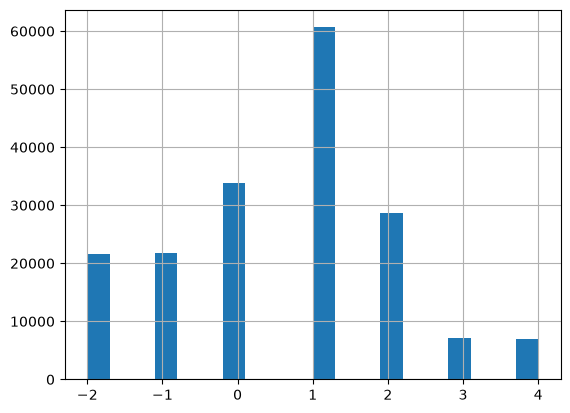

In [11]:
(df_clean['days_for_shipping_real'] - df_clean['days_for_shipment_scheduled']).hist(bins=20)

<Axes: xlabel='order_date_dateorders'>

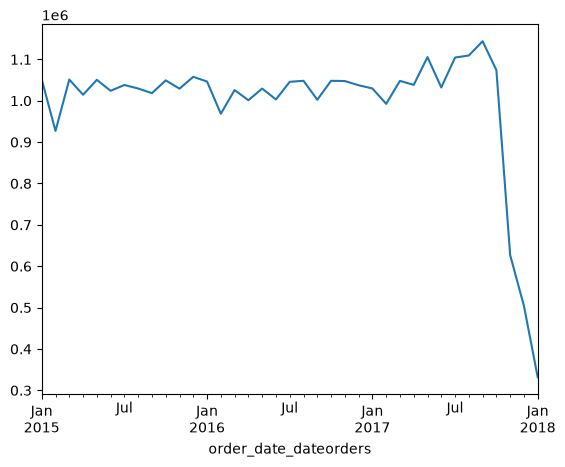

In [12]:
df_clean.groupby(df_clean['order_date_dateorders'].dt.to_period("M"))['sales'].sum().plot(kind='line')

<Axes: xlabel='order_region'>

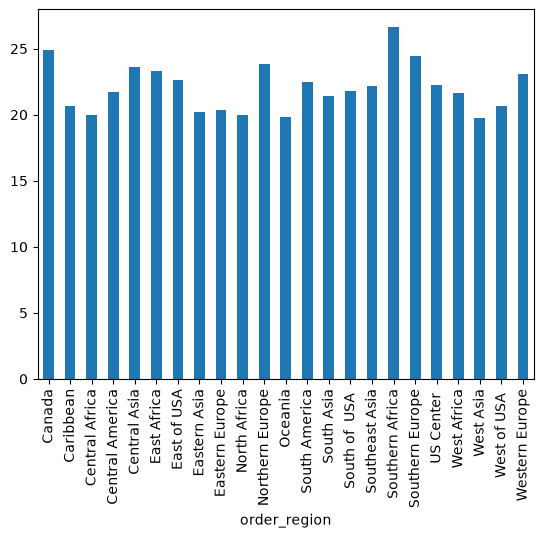

In [13]:
df_clean.groupby('order_region')['order_profit_per_order'].mean().plot(kind='bar')

<Axes: xlabel='shipping_mode'>

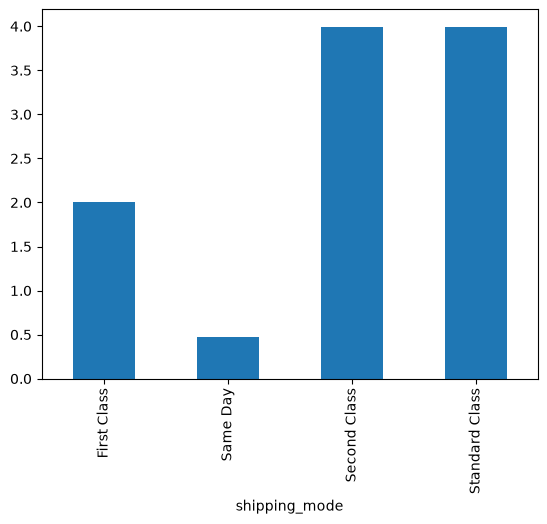

In [14]:
df_clean.groupby('shipping_mode')['days_for_shipping_real'].mean().plot(kind='bar')

In [15]:
rename_map = {
    "type": "payment_type",
    "order_date_dateorders": "order_date",
    "shipping_date_dateorders": "shipping_date",
    "order_item_cardprod_id": "order_item_product_id",
    # keep others as-is or mapped for clarity
}

df_clean = df_clean.rename(columns=rename_map)

print(df_clean.columns.tolist())

['payment_type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date', 'order_id', 'order_item_product_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'product_card_id', 'product_category_id', 'product_name', 'product_price', 'product_status', 'shipping_date', 'shipping_mode']


In [16]:
print(df_clean["order_date"].dtype)
print(df_clean["shipping_date"].dtype)

print("Order date:", df_clean["order_date"].min(), "to", df_clean["order_date"].max())
print("Shipping date:", df_clean["shipping_date"].min(), "to", df_clean["shipping_date"].max())

datetime64[us]
datetime64[us]
Order date: 2015-01-01 00:00:00 to 2018-01-31 23:38:00
Shipping date: 2015-01-03 00:00:00 to 2018-02-06 22:14:00


In [17]:
invalid_dates = df_clean[df_clean["shipping_date"] < df_clean["order_date"]]
print("Invalid shipping dates:", len(invalid_dates))

# Flag them instead of deleting
df_clean["date_quality_flag"] = df_clean["shipping_date"] < df_clean["order_date"]

Invalid shipping dates: 0


In [18]:
print(df_clean["order_item_quantity"].describe())

# Check for invalid quantities
invalid_qty = df_clean[df_clean["order_item_quantity"] <= 0]
print(invalid_qty)

count    180519.000000
mean          2.127638
std           1.453451
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max           5.000000
Name: order_item_quantity, dtype: float64
Empty DataFrame
Columns: [payment_type, days_for_shipping_real, days_for_shipment_scheduled, benefit_per_order, sales_per_customer, delivery_status, late_delivery_risk, category_id, category_name, customer_city, customer_country, customer_id, customer_segment, customer_state, customer_zipcode, department_id, department_name, latitude, longitude, market, order_city, order_country, order_customer_id, order_date, order_id, order_item_product_id, order_item_discount, order_item_discount_rate, order_item_id, order_item_product_price, order_item_profit_ratio, order_item_quantity, sales, order_item_total, order_profit_per_order, order_region, order_state, order_status, product_card_id, product_category_id, product_name, product_price, product_status, shipping_date, shipp

In [19]:
price_columns = [
    "product_price",
    "order_item_product_price",
    "sales",
    "order_item_total"
]

print(df_clean[price_columns].describe())

for col in price_columns:
    print(col, "negative values:", (df_clean[col] < 0).sum())

       product_price  order_item_product_price          sales  \
count  180519.000000             180519.000000  180519.000000   
mean      141.232550                141.232550     203.772096   
std       139.732492                139.732492     132.273077   
min         9.990000                  9.990000       9.990000   
25%        50.000000                 50.000000     119.980003   
50%        59.990002                 59.990002     199.919998   
75%       199.990005                199.990005     299.950012   
max      1999.989990               1999.989990    1999.989990   

       order_item_total  
count     180519.000000  
mean         183.107609  
std          120.043670  
min            7.490000  
25%          104.379997  
50%          163.990005  
75%          247.399994  
max         1939.989990  
product_price negative values: 0
order_item_product_price negative values: 0
sales negative values: 0
order_item_total negative values: 0


In [20]:
important_columns = [
    "order_id","order_date","shipping_date","delivery_status","late_delivery_risk",
    "shipping_mode","market","order_region","order_country","category_name",
    "product_name","order_item_quantity","sales","order_item_total","order_profit_per_order"
]

df_clean[important_columns].head()

,order_id,order_date,shipping_date,delivery_status,late_delivery_risk,shipping_mode,market,order_region,order_country,category_name,product_name,order_item_quantity,sales,order_item_total,order_profit_per_order
0,77202,2018-01-31 22:56:00,2018-02-03 22:56:00,Advance shipping,0,Standard Class,Pacific Asia,Southeast Asia,Indonesia,Sporting Goods,Smart watch,1,327.75,314.640015,91.250000
1,75939,2018-01-13 12:27:00,2018-01-18 12:27:00,Late delivery,1,Standard Class,Pacific Asia,South Asia,India,Sporting Goods,Smart watch,1,327.75,311.359985,-249.089996
2,75938,2018-01-13 12:06:00,2018-01-17 12:06:00,Shipping on time,0,Standard Class,Pacific Asia,South Asia,India,Sporting Goods,Smart watch,1,327.75,309.720001,-247.779999
3,75937,2018-01-13 11:45:00,2018-01-16 11:45:00,Advance shipping,0,Standard Class,Pacific Asia,Oceania,Australia,Sporting Goods,Smart watch,1,327.75,304.809998,22.860001
4,75936,2018-01-13 11:24:00,2018-01-15 11:24:00,Advance shipping,0,Standard Class,Pacific Asia,Oceania,Australia,Sporting Goods,Smart watch,1,327.75,298.250000,134.210007


In [21]:
print("Rows:", len(df_clean))
print("Unique Orders:", df_clean["order_id"].nunique())
print("Unique Order Items:", df_clean["order_item_id"].nunique())
print("Unique Customers:", df_clean["customer_id"].nunique())
print("Unique Products:", df_clean["product_card_id"].nunique())

Rows: 180519
Unique Orders: 65752
Unique Order Items: 180519
Unique Customers: 20652
Unique Products: 118


In [22]:
order_items_per_order = df_clean.groupby("order_id").size()
print(order_items_per_order.describe())

count    65752.000000
mean         2.745453
std          1.478363
min          1.000000
25%          1.000000
50%          3.000000
75%          4.000000
max          5.000000
dtype: float64


In [23]:
df_clean["delivery_delay_days"] = (
    df_clean["days_for_shipping_real"] - df_clean["days_for_shipment_scheduled"]
)

In [24]:
df_clean["on_time_flag"] = (df_clean["delivery_delay_days"] <= 0).astype(int)
print(df_clean["on_time_flag"].value_counts())

on_time_flag
0    103400
1     77119
Name: count, dtype: int64


In [25]:
import numpy as np

df_clean["delay_severity"] = np.select(
    [
        df_clean["delivery_delay_days"] <= 0,
        df_clean["delivery_delay_days"] == 1,
        df_clean["delivery_delay_days"].between(2, 3),
        df_clean["delivery_delay_days"] >= 4
    ],
    [
        "On Time",
        "1 Day Late",
        "2-3 Days Late",
        "4+ Days Late"
    ],
    default="Unknown"
)

print(df_clean["delay_severity"].value_counts())

delay_severity
On Time          77119
1 Day Late       60647
2-3 Days Late    35770
4+ Days Late      6983
Name: count, dtype: int64


In [26]:
df_clean[
    ["sales","order_item_total","order_item_product_price","order_item_quantity","order_item_discount"]
].head(10)

,sales,order_item_total,order_item_product_price,order_item_quantity,order_item_discount
0,327.75,314.640015,327.75,1,13.110000
1,327.75,311.359985,327.75,1,16.389999
2,327.75,309.720001,327.75,1,18.030001
3,327.75,304.809998,327.75,1,22.940001
4,327.75,298.250000,327.75,1,29.500000
5,327.75,294.980011,327.75,1,32.779999
6,327.75,288.420013,327.75,1,39.330002
7,327.75,285.140015,327.75,1,42.610001
8,327.75,278.589996,327.75,1,49.160000
9,327.75,275.309998,327.75,1,52.439999


In [27]:
df_clean["calculated_gross_value"] = (
    df_clean["order_item_product_price"] * df_clean["order_item_quantity"]
)

df_clean[["calculated_gross_value","order_item_total","sales"]].head(10)

,calculated_gross_value,order_item_total,sales
0,327.75,314.640015,327.75
1,327.75,311.359985,327.75
2,327.75,309.720001,327.75
3,327.75,304.809998,327.75
4,327.75,298.250000,327.75
5,327.75,294.980011,327.75
6,327.75,288.420013,327.75
7,327.75,285.140015,327.75
8,327.75,278.589996,327.75
9,327.75,275.309998,327.75


In [28]:
df_clean["discount_amount"] = df_clean["order_item_discount"]
print(df_clean["discount_amount"].describe())

count    180519.000000
mean         20.664741
std          21.800901
min           0.000000
25%           5.400000
50%          14.000000
75%          29.990000
max         500.000000
Name: discount_amount, dtype: float64


In [29]:
df_clean["order_item_profit_ratio"].describe()

count    180519.000000
mean          0.120647
std           0.466796
min          -2.750000
25%           0.080000
50%           0.270000
75%           0.360000
max           0.500000
Name: order_item_profit_ratio, dtype: float64

In [30]:
df_clean["profit_margin_pct"] = df_clean["order_item_profit_ratio"] * 100

In [31]:
df_clean["year"] = df_clean["order_date"].dt.year
df_clean["month"] = df_clean["order_date"].dt.month
df_clean["month_name"] = df_clean["order_date"].dt.month_name()
df_clean["quarter"] = df_clean["order_date"].dt.quarter
df_clean["year_month"] = df_clean["order_date"].dt.to_period("M").astype(str)

In [32]:
import numpy as np

df_clean["delivery_risk"] = np.select(
    [
        df_clean["delivery_delay_days"] <= 0,
        df_clean["delivery_delay_days"].between(1, 2),
        df_clean["delivery_delay_days"] >= 3
    ],
    [
        "Low",
        "Medium",
        "High"
    ],
    default="Unknown"
)

In [33]:
print(
    df_clean[
        ["delivery_delay_days","on_time_flag","delay_severity","delivery_risk"]
    ].head(20)
)

print(df_clean["delivery_risk"].value_counts())

    delivery_delay_days  on_time_flag delay_severity delivery_risk
0                    -1             1        On Time           Low
1                     1             0     1 Day Late        Medium
2                     0             1        On Time           Low
3                    -1             1        On Time           Low
4                    -2             1        On Time           Low
5                     2             0  2-3 Days Late        Medium
6                     1             0     1 Day Late        Medium
7                     1             0     1 Day Late        Medium
8                     1             0     1 Day Late        Medium
9                     1             0     1 Day Late        Medium
10                    4             0   4+ Days Late          High
11                    3             0  2-3 Days Late          High
12                    2             0  2-3 Days Late        Medium
13                    1             0     1 Day Late        Me

In [34]:
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("Duplicate rows:", df_clean.duplicated().sum())

missing_final = (
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
)
print(missing_final[missing_final > 0])

print(df_clean.dtypes)

print("Unique orders:", df_clean["order_id"].nunique())
print("Unique customers:", df_clean["customer_id"].nunique())
print("Unique products:", df_clean["product_card_id"].nunique())

Rows: 180519
Columns: 58
Duplicate rows: 0
Series([], dtype: int64)
payment_type                              str
days_for_shipping_real                  int64
days_for_shipment_scheduled             int64
benefit_per_order                     float64
sales_per_customer                    float64
delivery_status                           str
late_delivery_risk                      int64
category_id                             int64
category_name                             str
customer_city                             str
customer_country                          str
customer_id                             int64
customer_segment                          str
customer_state                            str
customer_zipcode                      float64
department_id                           int64
department_name                           str
latitude                              float64
longitude                             float64
market                                    str
order_city  

In [35]:
output_path = "../data/processed/dataco_supply_chain_clean.csv"

df_clean.to_csv(output_path, index=False)
print("Clean dataset saved successfully!")

import os
print(os.path.getsize(output_path))

test_df = pd.read_csv(output_path)
print(test_df.shape)
print(test_df.head())

Clean dataset saved successfully!
90177983
(180519, 58)
  payment_type  days_for_shipping_real  days_for_shipment_scheduled  \
0        DEBIT                       3                            4   
1     TRANSFER                       5                            4   
2         CASH                       4                            4   
3        DEBIT                       3                            4   
4      PAYMENT                       2                            4   

   benefit_per_order  sales_per_customer   delivery_status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   late_delivery_risk  category_id   category_name customer_city  ...  \
0                   0           73  Sporting Goods        Caguas  ...  

In [36]:
print(df_clean.columns.tolist())

['payment_type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_id', 'customer_segment', 'customer_state', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date', 'order_id', 'order_item_product_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'product_card_id', 'product_category_id', 'product_name', 'product_price', 'product_status', 'shipping_date', 'shipping_mode', 'date_quality_flag', 'delivery_delay_days', 'on_time_flag', 'delay_severity', 'calculated_gross_value', 'discount_amount', 'profit_margin_pct', 'year',

In [37]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("../data/processed/dataco_supply_chain_clean.csv")

# --- Customers ---
customers = df[["customer_id","customer_segment","customer_city",
                "customer_state","customer_country","customer_zipcode"]].drop_duplicates()
customers.to_csv("../data/processed/customers.csv", index=False)

# --- Products ---
products = df[["product_card_id","product_category_id","category_id",
               "category_name","product_name","product_price","product_status"]].drop_duplicates()
products.to_csv("../data/processed/products.csv", index=False)

# --- Orders ---
orders = df[["order_id","order_date","shipping_date","order_status","order_region",
             "order_country","order_state","order_city","market","payment_type","customer_id"]].drop_duplicates()
orders.to_csv("../data/processed/orders.csv", index=False)

# --- Order_Items ---
order_items = df[["order_item_id","order_id","product_card_id","order_item_product_price",
                  "order_item_quantity","order_item_discount","order_item_discount_rate",
                  "order_item_total","order_profit_per_order","order_item_profit_ratio"]]
order_items.to_csv("../data/processed/order_items.csv", index=False)
